In [1]:
import torch
from dinosaw.helpers import ModelTypes, model_names, get_models,get_features, add_custom_font
from dinosaw.utils import do_2D_pca

import numpy as np
from PIL import Image

import matplotlib.pyplot as plt

SEED = 100001
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = 'cuda:1'
half = False

flash attention installed


In [28]:
enabled_models: tuple[ModelTypes, ...] = ('dv2', 'sinusoid_dv2', 'nope', 'alibi_dv2_coco') #'dv2',
models = get_models(enabled_models, "../../trained_models", DEVICE, half)

data_dir = "../paper_figures/data/nope_vs_alibi"

imgs = ("plant_cells.jpg", "cat_sketch.jpeg", "deer_sketch.png")

torch.Size([1, 256, 384])


In [33]:
channel_group = 0
features, features_reduced = [], {model_key: {} for model_key in enabled_models}
for img_file in imgs:
    for model_key in enabled_models:
        model = models[model_key]
        img_path = f'{data_dir}/{img_file}'
        img = Image.open(img_path).convert('RGB')
        sf_calc = 518 / img.height
        if img_file == "plant_cells.jpg":
            sf_calc = 1
        img = img.resize((int(sf_calc * img.width), int(sf_calc * img.height)), Image.LANCZOS)
        feats = get_features(model, img, device=DEVICE, channel_last=False, to_half=half)#.cpu()
        features_reduced[model_key][img_file] =  do_2D_pca(feats, (channel_group+1)*3, post_norm='minmax')[:, :, channel_group*3:channel_group*3+3]

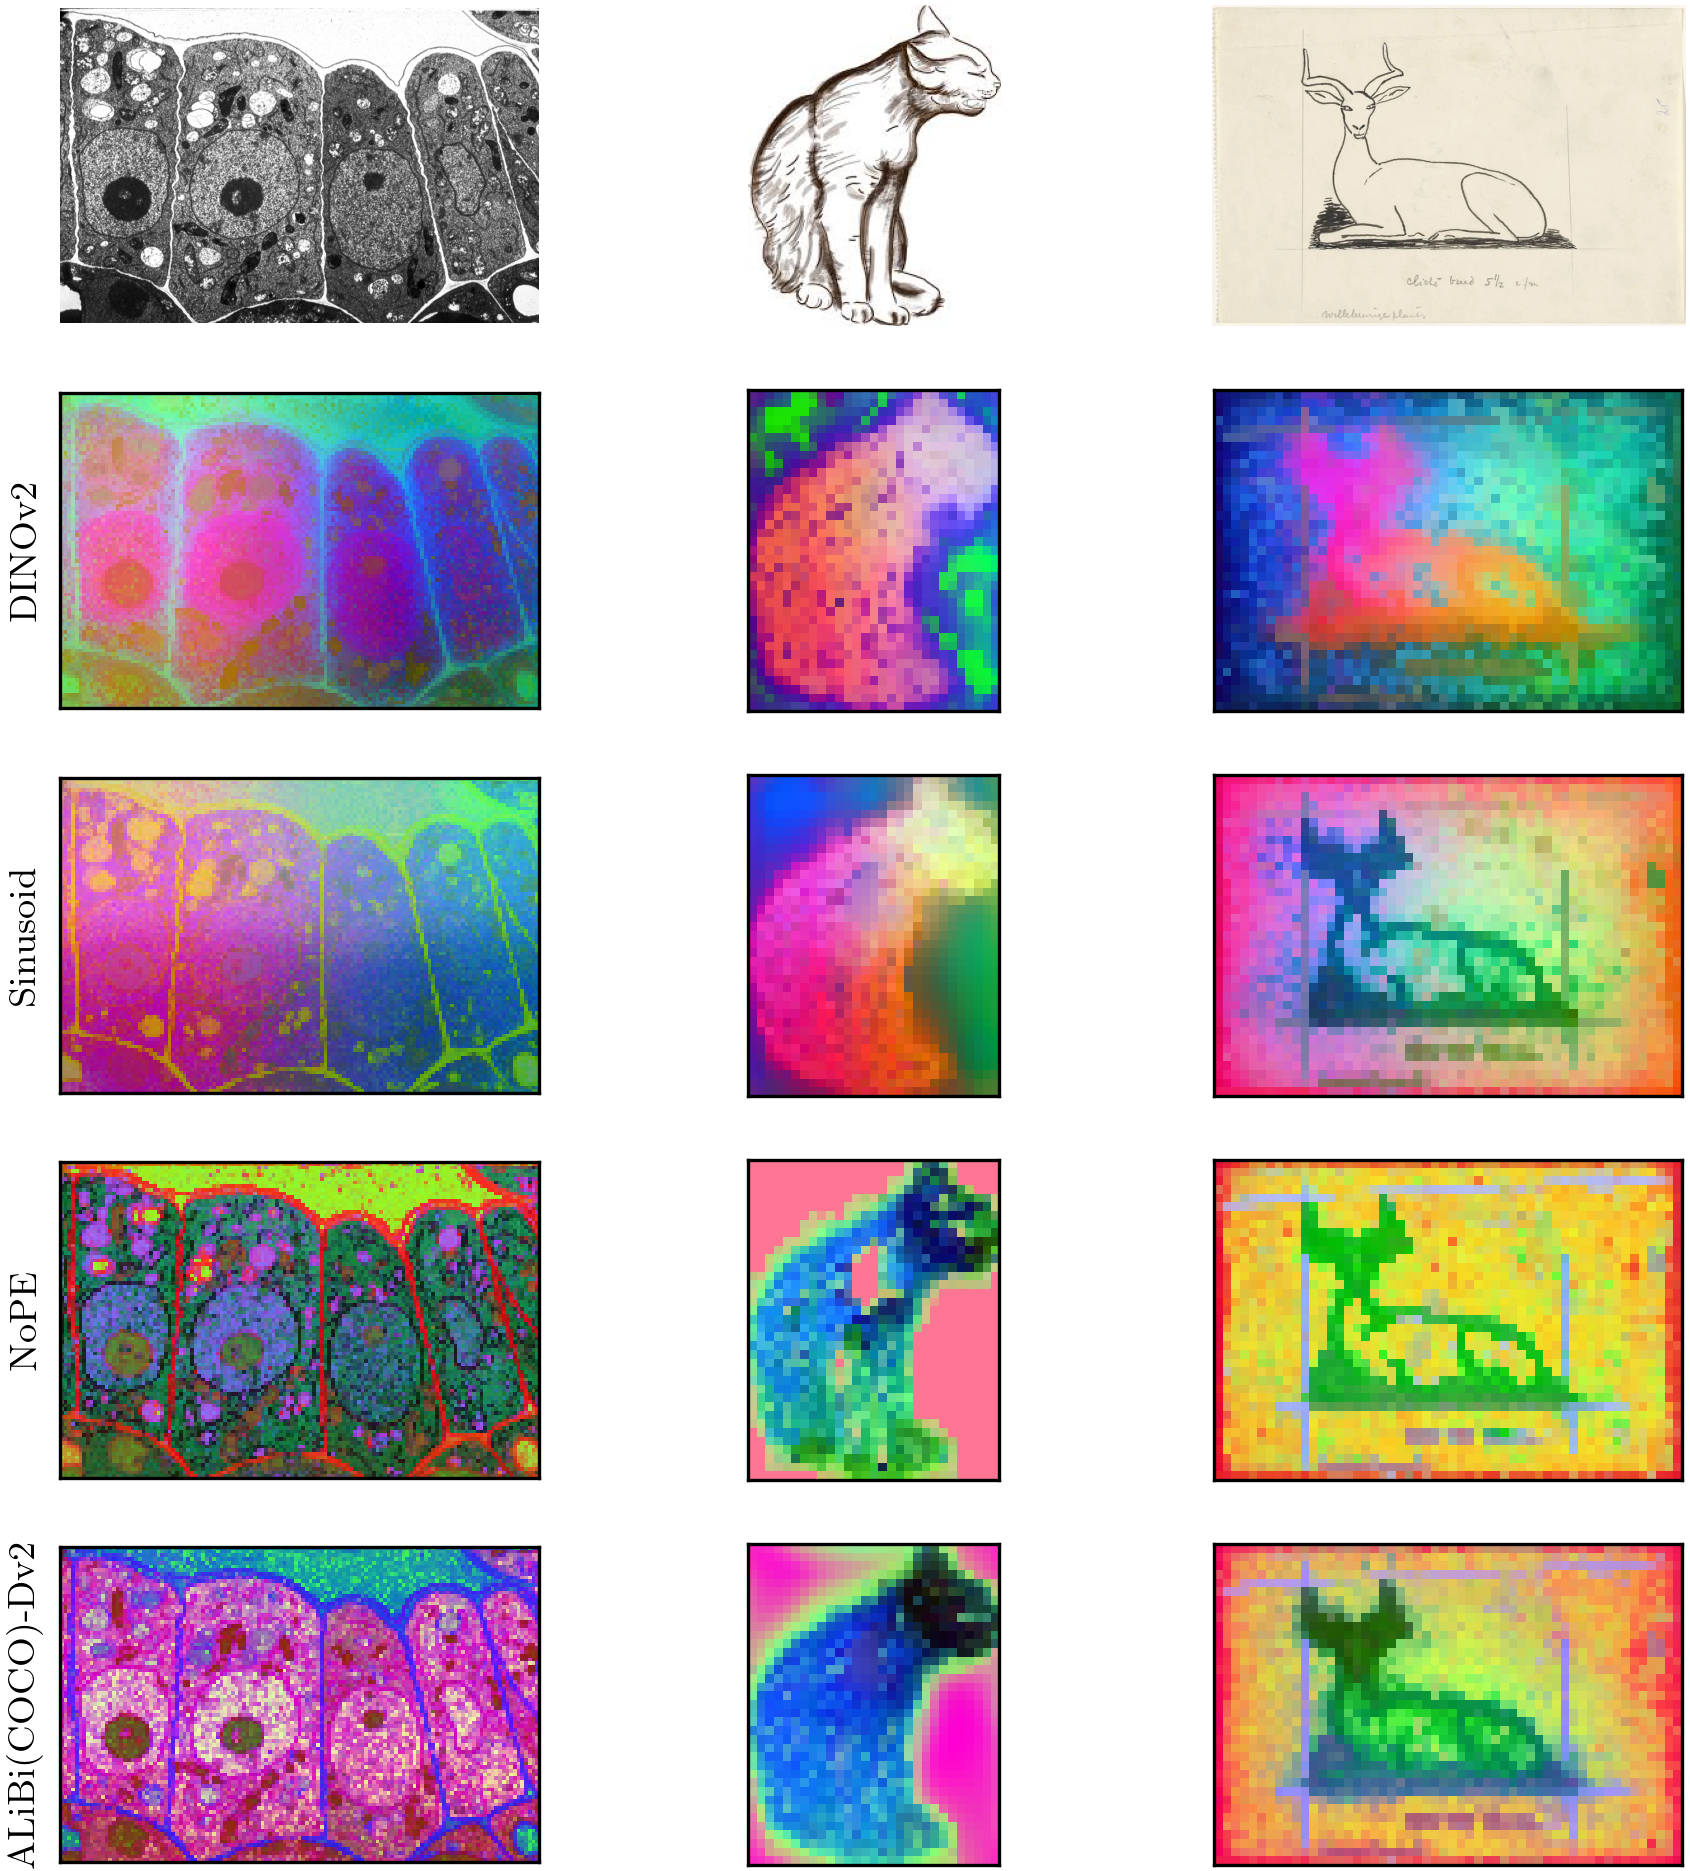

In [ ]:
# %%capture
plt.style.use("thesis.mplstyle")

from matplotlib.gridspec import GridSpec

NCOLS=len(imgs)
NROWS = 1 + len(enabled_models)
# H,W = 14,19

# fig, axs = plt.subplots(nrows=NROWS, ncols=NCOLS, figsize=(25, 25), gridspec_kw={"hspace":0.5})
fig = plt.figure(figsize=(7, 2.3 * (3.5)))
gs = GridSpec(NROWS, NCOLS, figure=fig)



for i, img_file in enumerate(imgs):
    ax = fig.add_subplot(gs[0, i])
    ax.imshow(Image.open(f"{data_dir}/{img_file}").convert("RGB"))
    ax.set_axis_off()
    for j, model_key in enumerate(enabled_models):
        ax = fig.add_subplot(gs[j+1, i])
        feats=features_reduced[model_key][img_file]
        ax.imshow(feats,)
        ax.set_yticks([])
        ax.set_xticks([])
        if i==0:
            model_name = model_names[model_key]
            label = f"\textbf{{{model_name.strip('(COCO)')}}}" if "alibi" in model_key else model_name
            ax.set_ylabel(model_names[model_key], fontweight="bold" if "alibi" in model_key else None)
# plt.tight_layout()
plt.savefig("out/nope_v_alibi.pdf", dpi=300, bbox_inches='tight',)